# Week 5: Support Vector Machines

In [1]:
import os

import kagglehub
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

In [2]:
cached_path = os.path.expanduser(
    "~/.cache/kagglehub/datasets/rabieelkharoua/"
    "predict-conversion-in-digital-marketing-dataset/versions/1"
)

if os.path.exists(cached_path):
    path = cached_path
else:
    path = kagglehub.dataset_download(
        "rabieelkharoua/predict-conversion-in-digital-marketing-dataset"
    )

df_m = pd.read_csv(os.path.join(path, "digital_marketing_campaign_dataset.csv"))
df_m.head()

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


In [3]:
target = "Conversion"

features = [
    "Age",
    "Income",
    "AdSpend",
    "ClickThroughRate",
    "WebsiteVisits",
    "PagesPerVisit",
    "TimeOnSite",
    "EmailOpens",
    "EmailClicks",
    "PreviousPurchases",
    "LoyaltyPoints",
]

data = df_m[[target] + features].dropna()

X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['Age', 'Income', 'AdSpend', 'ClickThroughRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints']
Categorical columns: []


In [4]:
preprocess_steps = [("num", StandardScaler(), numeric_cols)]

if categorical_cols:
    try:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

    preprocess_steps.append(("cat", encoder, categorical_cols))

preprocessor = ColumnTransformer(preprocess_steps)

SVM styles: linear, RBF, and polynomial. The `C` values are the regularization check, where smaller `C` is tougher and larger `C` lets the model fit the training data more closely

In [5]:
svm_models = [
    {"Model": "Linear SVM", "kernel": "linear"},
    {"Model": "RBF Kernel SVM", "kernel": "rbf"},
    {"Model": "Polynomial Kernel SVM", "kernel": "poly", "degree": 3},
]

c_values = [0.1, 1, 10]
results = []

for model_info in svm_models:
    for c_value in c_values:
        svm = SVC(
            C=c_value,
            kernel=model_info["kernel"],
            degree=model_info.get("degree", 3),
            probability=True,
            random_state=42,
        )

        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("svm", svm),
        ])

        pipe.fit(X_train, y_train)

        y_pred = pipe.predict(X_test)
        y_proba = pipe.predict_proba(X_test)[:, 1]
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        results.append({
            "Model": model_info["Model"],
            "Kernel": model_info["kernel"],
            "C": c_value,
            "Accuracy": accuracy_score(y_test, y_pred),
            "ROC AUC": roc_auc_score(y_test, y_proba),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1": f1_score(y_test, y_pred, zero_division=0),
            "Confusion Matrix": [[tn, fp], [fn, tp]],
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
        })

svm_results_df = pd.DataFrame(results)
svm_results_df.sort_values("ROC AUC", ascending=False).round(4)

,Model,Kernel,C,Accuracy,ROC AUC,Precision,Recall,F1,Confusion Matrix,TN,FP,FN,TP
8,Polynomial Kernel SVM,poly,10.0,0.8900,0.7357,0.8955,0.9900,0.9404,"[[36, 162], [14, 1388]]",36,162,14,1388
3,RBF Kernel SVM,rbf,0.1,0.8762,0.7340,0.8762,1.0000,0.9340,"[[0, 198], [0, 1402]]",0,198,0,1402
4,RBF Kernel SVM,rbf,1.0,0.8825,0.7307,0.8852,0.9950,0.9369,"[[17, 181], [7, 1395]]",17,181,7,1395
7,Polynomial Kernel SVM,poly,1.0,0.8862,0.7293,0.8895,0.9936,0.9387,"[[25, 173], [9, 1393]]",25,173,9,1393
6,Polynomial Kernel SVM,poly,0.1,0.8781,0.7277,0.8779,1.0000,0.9350,"[[3, 195], [0, 1402]]",3,195,0,1402
5,RBF Kernel SVM,rbf,10.0,0.8875,0.7185,0.9036,0.9757,0.9383,"[[52, 146], [34, 1368]]",52,146,34,1368
1,Linear SVM,linear,1.0,0.8762,0.6920,0.8762,1.0000,0.9340,"[[0, 198], [0, 1402]]",0,198,0,1402
0,Linear SVM,linear,0.1,0.8762,0.6534,0.8762,1.0000,0.9340,"[[0, 198], [0, 1402]]",0,198,0,1402
2,Linear SVM,linear,10.0,0.8762,0.6522,0.8762,1.0000,0.9340,"[[0, 198], [0, 1402]]",0,198,0,1402


In [6]:
best_result = svm_results_df.sort_values("ROC AUC", ascending=False).iloc[0]

print("Best model by ROC AUC")
print(best_result[["Model", "C", "Accuracy", "ROC AUC", "Precision", "Recall", "F1", "FP"]])

Best model by ROC AUC
Model        Polynomial Kernel SVM
C                             10.0
Accuracy                      0.89
ROC AUC                   0.735727
Precision                 0.895484
Recall                    0.990014
F1                        0.940379
FP                             162
Name: 8, dtype: object


In [7]:
best_svm = svm_results_df.sort_values("ROC AUC", ascending=False).iloc[0]

print("Best model by ROC AUC")
print(best_svm[["Model", "C", "Accuracy", "ROC AUC", "Precision", "Recall", "F1"]])
print("Confusion matrix:")
print(np.array(best_svm["Confusion Matrix"]))

Best model by ROC AUC
Model        Polynomial Kernel SVM
C                             10.0
Accuracy                      0.89
ROC AUC                   0.735727
Precision                 0.895484
Recall                    0.990014
F1                        0.940379
Name: 8, dtype: object
Confusion matrix:
[[  36  162]
 [  14 1388]]


In [8]:
best_svm = SVC(
    kernel=best_result["Kernel"],
    C=best_result["C"],
    degree=3,
    probability=True,
    random_state=42
)

best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("svm", best_svm),
])

best_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Income', 'AdSpend',
                                                   'ClickThroughRate',
                                                   'WebsiteVisits',
                                                   'PagesPerVisit',
                                                   'TimeOnSite', 'EmailOpens',
                                                   'EmailClicks',
                                                   'PreviousPurchases',
                                                   'LoyaltyPoints'])])),
                ('svm',
                 SVC(C=np.float64(10.0), kernel='poly', probability=True,
                     random_state=42))])

<Figure size 600x500 with 0 Axes>

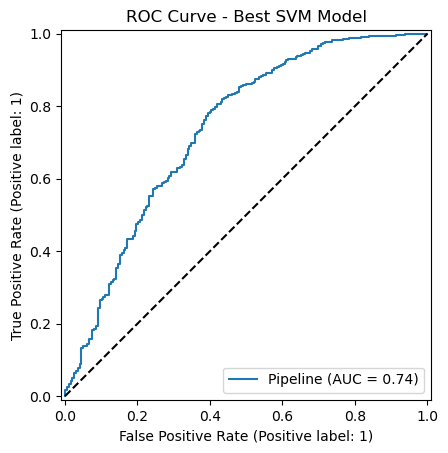

In [9]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

RocCurveDisplay.from_estimator(best_model, X_test, y_test)

plt.plot([0,1],[0,1],"k--")
plt.title("ROC Curve - Best SVM Model")

plt.show()

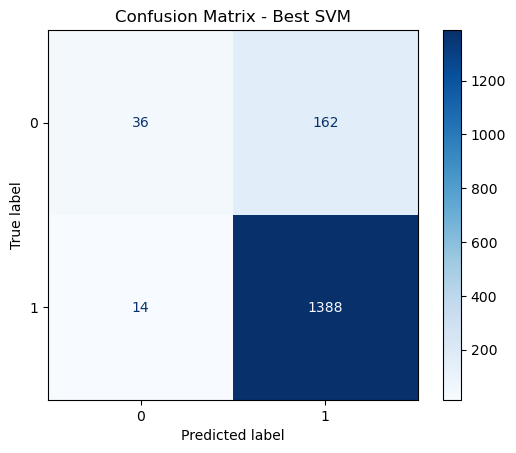

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Best SVM")
plt.show()

## Best SVM Notes

The best SVM was the polynomial kernel with `C=10`. Its ROC AUC was about `0.736`, and it had `162` false positives, so it caught conversions well but still predicted some conversions that did not actually happen.

In [11]:
print(
    f"Best kernel: {best_result['Kernel']}, "
    f"C: {best_result['C']}, "
    f"ROC AUC: {best_result['ROC AUC']:.3f}, "
    f"False positives: {int(best_result['FP'])}"
)

Best kernel: poly, C: 10.0, ROC AUC: 0.736, False positives: 162
